# Plot Training Curvers

In [8]:
from matplotlib import pyplot as plt
import numpy as np
import os


BASE_DIR = './experiments/logs'

data_files = {"ecot": "EVAL-libero_object-openvla-2025_03_28-17_22_00.npy",
             "ecot-batch": "EVAL-libero_object-openvla-2025_03_28-17_21_39.npy"}

# Load Data
data_dict = {}
for k, v in data_files.items():
    filepath = os.path.join(BASE_DIR, v)
    combined_actions = np.load(filepath)
    print(k, combined_actions.shape)
    faith_scores = np.sum(np.abs(combined_actions - combined_actions[:, 8:, :]), axis=-1)  # [N, 9]
    data_dict[k] = faith_scores

xs = range(9)

ecot (280, 9, 7)
ecot-batch (116, 9, 7)


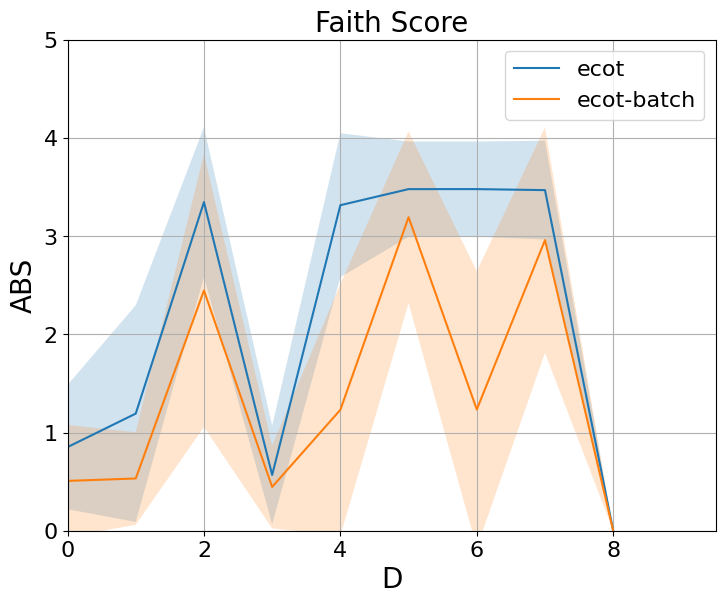

In [ ]:
# plot Success
file_name = "faith"
xname = '# Subtasks in Reasoning Chain'
yname = 'Sum Abs Error of Actions'
y_min, y_max = 0, 5
x_min, x_max = 0, 9.5
weight = 0.9
variance = 0.25
alpha = 0.2

# smooth function for plots
def smooth(scalars, weight):  # Weight between 0 and 1
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor the last smoothed value
    return smoothed

fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
fig.subplots_adjust(left=0.14, bottom=0.132, top=0.95, right=0.95)

ax1.set_title(ax_name, fontsize=20)
ax1.set_xlabel(xname, fontsize=20)
ax1.set_ylabel(yname, fontsize=20)
ax1.set_ylim((y_min, y_max))
ax1.set_xlim((x_min, x_max))
ax1.tick_params(labelsize=16)

for k, v in data_dict.items():
    y_mean = np.mean(v, axis=0)
    y_std = np.std(v, axis=0)
    ax1.plot(xs, y_mean, label=k, linewidth=1.5)
    ax1.fill_between(xs, y_mean - y_std, y_mean + y_std, alpha=alpha)

ax1.grid()
ax1.legend(fontsize=16) # , loc='lower right')

            
            